### Cell 1: Imports and Data Prep

In [1]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add src to path
sys.path.append(os.path.abspath('../src'))
from analysis_utils import load_data, prepare_modeling_data

# Load data
df = load_data('../data/BrentOilPrices.csv')
# For Bayesian models, using a subset or downsampling (e.g., weekly) 
# can speed up initial testing, but here we use the full data.
y, x = prepare_modeling_data(df)

c:\Users\user\.conda\envs\brent_env\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


### Cell 2: The Bayesian Change Point Model (The Core)

In [2]:
with pm.Model() as change_point_model:
    # 1. Prior for the Switch Point (Discrete Uniform over all days)
    # instructions: "Define it as a discrete uniform prior"
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(y) - 1)
    
    # 2. Priors for "Before" and "After" price means
    # We use the mean of the data as a starting point for the prior
    mu_1 = pm.Normal("mu_1", mu=y.mean(), sigma=y.std())
    mu_2 = pm.Normal("mu_2", mu=y.mean(), sigma=y.std())
    
    # 3. Prior for standard deviation (assumed constant for this simple model)
    sigma = pm.Exponential("sigma", 1.0)
    
    # 4. Use Switch Function: selection based on whether time index is < tau
    # instructions: "Use pm.math.switch to select the correct parameter"
    mu_weighted = pm.math.switch(tau > x, mu_1, mu_2)
    
    # 5. Likelihood
    # instructions: "Connect model to data using a pm.Normal distribution"
    observation = pm.Normal("obs", mu=mu_weighted, sigma=sigma, observed=y)
    
    # 6. Run Sampler
    # instructions: "Use pm.sample() to run the MCMC simulation"
    trace = pm.sample(2000, tune=1000, return_inferencedata=True, cores=1)

INFO: Compiling new CVM
INFO: New version 0.31
Sequential sampling (2 chains in 1 job)
INFO: Sequential sampling (2 chains in 1 job)
CompoundStep
INFO: CompoundStep
>Metropolis: [tau]
INFO: >Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]
INFO: >NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 12 seconds.
INFO: Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 12 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
INFO: We recommend running at least 4 chains for robust computation of convergence diagnostics


### Cell 3: Interpretation - Convergence & Trace Plots

           mean     sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau    4520.966  3.250  4514.000  4526.000      0.111    0.091     878.0   
mu_1     21.429  0.269    20.947    21.936      0.004    0.005    5867.0   
mu_2     75.607  0.275    75.111    76.148      0.004    0.004    5962.0   
sigma    18.579  0.139    18.335    18.848      0.002    0.002    5974.0   

       ess_tail  r_hat  
tau       827.0    1.0  
mu_1     2750.0    1.0  
mu_2     3207.0    1.0  
sigma    3374.0    1.0  


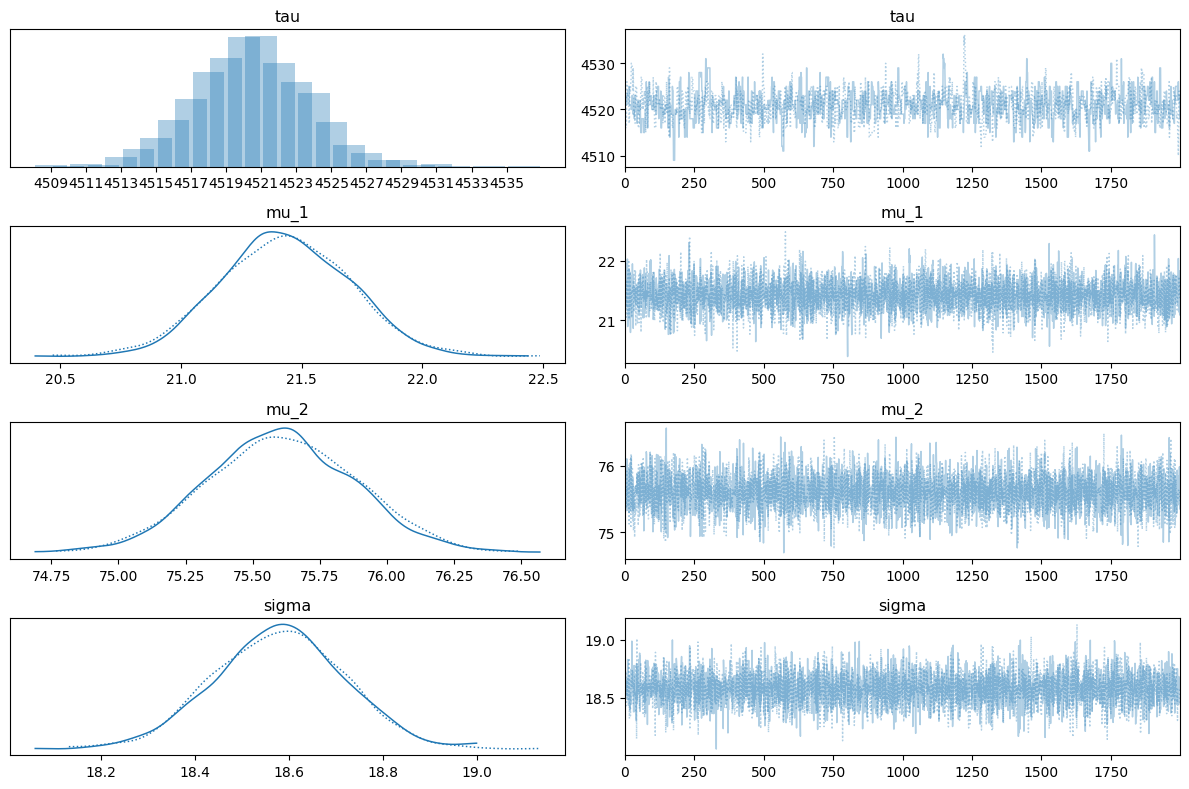

In [3]:
# Check for Convergence (r_hat should be close to 1.0)
summary = az.summary(trace)
print(summary)

# Visualizing the chains
az.plot_trace(trace)
plt.tight_layout()
plt.show()

### Cell 4: Visualizing the Change Point ($\tau$)

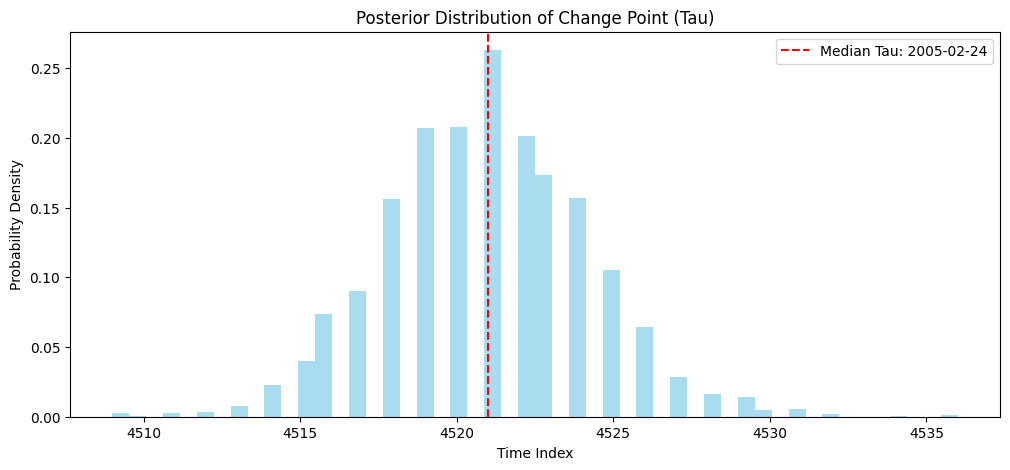

The model detected a structural break around: 2005-02-24


In [4]:
# Extract the posterior of tau
tau_samples = trace.posterior['tau'].values.flatten()

# Convert index back to Date
detected_index = int(np.rint(np.median(tau_samples)))
detected_date = df.index[detected_index]

plt.figure(figsize=(12, 5))
plt.hist(tau_samples, bins=50, density=True, color='skyblue', alpha=0.7)
plt.axvline(detected_index, color='red', linestyle='--', label=f'Median Tau: {detected_date.date()}')
plt.title("Posterior Distribution of Change Point (Tau)")
plt.xlabel("Time Index")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

print(f"The model detected a structural break around: {detected_date.date()}")

### Cell 5: Quantifying Impact & Association with Events

In [5]:
# Get posterior means
mu1_samples = trace.posterior['mu_1'].values.flatten()
mu2_samples = trace.posterior['mu_2'].values.flatten()

mean_before = mu1_samples.mean()
mean_after = mu2_samples.mean()
percentage_change = ((mean_after - mean_before) / mean_before) * 100

print(f"Average Price Before: ${mean_before:.2f}")
print(f"Average Price After: ${mean_after:.2f}")
print(f"Impact: {percentage_change:.2f}% shift in price regime.")

# Associate with researched events
import pandas as pd
events = pd.read_csv('../data/external_events.csv')
events['Date'] = pd.to_datetime(events['Date'])

# Find the closest event to the detected date
events['days_diff'] = (events['Date'] - detected_date).abs()
closest_event = events.sort_values('days_diff').iloc[0]

print(f"\nClosest Historical Event: {closest_event['Event']} on {closest_event['Date'].date()}")

Average Price Before: $21.43
Average Price After: $75.61
Impact: 252.82% shift in price regime.

Closest Historical Event: US Invasion of Iraq on 2003-03-20
